In [28]:
print("Hello")

Hello


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [30]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/diamonds.csv"
df = pd.read_csv(url)
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [31]:
df.shape

(53940, 10)

In [32]:
print("Dataset column: ", df.columns.tolist())
print("Data types: ", df.dtypes)
print("Missing values: ", df.isnull().sum())
print("Summary statistics: ", df.describe())

Dataset column:  ['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y', 'z']
Data types:  carat      float64
cut            str
color          str
clarity        str
depth      float64
table      float64
price        int64
x          float64
y          float64
z          float64
dtype: object
Missing values:  carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64
Summary statistics:                carat         depth         table         price             x  \
count  53940.000000  53940.000000  53940.000000  53940.000000  53940.000000   
mean       0.797940     61.749405     57.457184   3932.799722      5.731157   
std        0.474011      1.432621      2.234491   3989.439738      1.121761   
min        0.200000     43.000000     43.000000    326.000000      0.000000   
25%        0.400000     61.000000     56.000000    950.000000      4.710000   
50%        0.700000     61.80000

In [33]:
# Data cleaning
duplicates = df.duplicated().sum()
print("Number of duplicate rows: ", duplicates)

Number of duplicate rows:  146


In [34]:
if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicate rows removed. New shape: ", df.shape)

Duplicate rows removed. New shape:  (53794, 10)


In [35]:
# Check if any dimension (x, y, z) has zero or negative values
invalid_dimensions_mask = (df['x'] <= 0) | (df['y'] <= 0) | (df['z'] <= 0)
invalid_count = invalid_dimensions_mask.sum()
print("Number of rows with invalid dimensions: ", invalid_count)

Number of rows with invalid dimensions:  19


In [36]:
if invalid_count > 0:
    df = df[~invalid_dimensions_mask]
    print("Invalid dimension rows removed. New shape: ", df.shape)

Invalid dimension rows removed. New shape:  (53775, 10)


In [37]:
# Convert ordered categorical quality into ordered categories
mean_by_cut = df.groupby('cut')['price'].mean().sort_values()
print("Mean price by cut: ", mean_by_cut)

Mean price by cut:  cut
Ideal        3462.148150
Good         3916.279051
Very Good    3980.920202
Fair         4340.677520
Premium      4578.913809
Name: price, dtype: float64


In [38]:
# Convert categorical columns to category data type
cut_order = ['Ideal', 'Good', 'Very Good',  'Fair', 'Premium']
df['cut'] = pd.Categorical(df['cut'], categories=cut_order, ordered=True)

In [39]:
df_before_trim = df.copy()
# Percentile based trimming for removing extreme outliers
depth_low, depth_high = np.percentile(df['depth'], [1, 99])

trim_mask = (df['depth'] >= depth_low) & (df['depth'] <= depth_high)
df = df[trim_mask]
print("Data shape after trimming: ", df.shape)

Data shape after trimming:  (52769, 10)


In [40]:
# Create volume out of x, y, z
df['volume'] = df['x'] * df['y'] * df['z']
# Build a custom score for cut
df['cut_score'] = df['cut'].cat.codes + 1  # +1 to make it 1-based

In [41]:
# correlation analysis
corr_mattrix = df.corr(numeric_only=True)
print("Correlation matrix: ", corr_mattrix)
print("Correlation with price: ", corr_mattrix['price'].sort_values(ascending=False))

Correlation matrix:                carat     depth     table     price         x         y  \
carat      1.000000  0.012615  0.186034  0.924672  0.978790  0.954569   
depth      0.012615  1.000000 -0.284400 -0.016242 -0.032545 -0.035565   
table      0.186034 -0.284400  1.000000  0.132525  0.195588  0.184531   
price      0.924672 -0.016242  0.132525  1.000000  0.889192  0.869003   
x          0.978790 -0.032545  0.195588  0.889192  1.000000  0.974500   
y          0.954569 -0.035565  0.184531  0.869003  0.974500  1.000000   
z          0.961511  0.072600  0.159126  0.871195  0.976916  0.957909   
volume     0.977793 -0.004215  0.171273  0.906112  0.958558  0.977602   
cut_score  0.162306 -0.130340  0.512579  0.112588  0.167917  0.150734   

                  z    volume  cut_score  
carat      0.961511  0.977793   0.162306  
depth      0.072600 -0.004215  -0.130340  
table      0.159126  0.171273   0.512579  
price      0.871195  0.906112   0.112588  
x          0.976916  0.958558   0

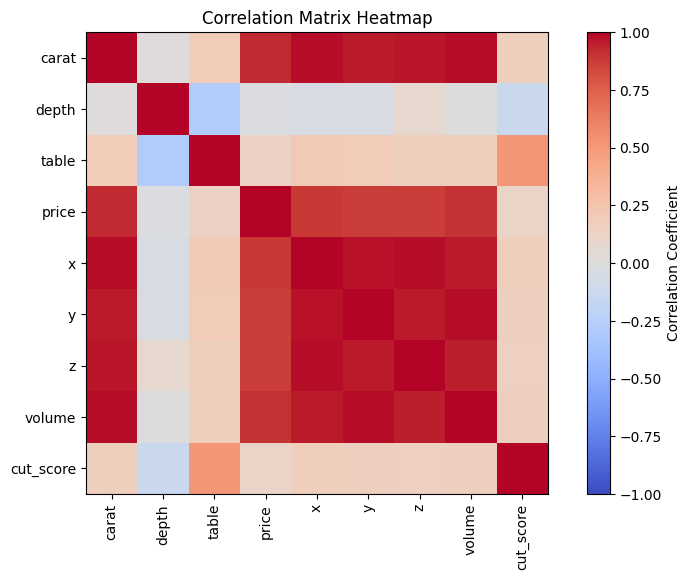

In [42]:
plt.figure(figsize=(10, 6))
plt.imshow(corr_mattrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation Coefficient')
plt.xticks(range(len(corr_mattrix)), corr_mattrix.columns, rotation=90)
plt.yticks(range(len(corr_mattrix)), corr_mattrix.columns)
plt.title('Correlation Matrix Heatmap')
plt.show()

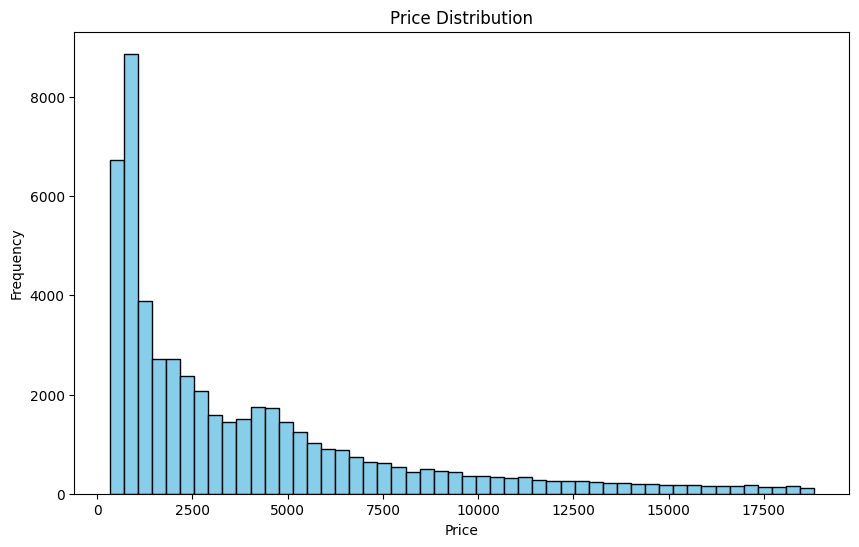

In [43]:
plt.figure(figsize=(10, 6))
plt.hist(df['price'], bins=50, color='skyblue', edgecolor='black')
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()